In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path



In [4]:
DATASET_PATH = Path("UCI-HAR-Dataset")

features = pd.read_csv(DATASET_PATH / "features.txt",sep=r'\s+', header=None, names=["idx", "feature"])
feature_names = features["feature"].values

has_duplicates = len(feature_names) != len(set(feature_names))
print(has_duplicates)

from collections import Counter


counts = Counter(feature_names)
duplicates = [item for item, count in counts.items() if count > 1]

print(len(duplicates))

True
42


In [5]:
activity_labels = pd.read_csv(DATASET_PATH / "activity_labels.txt",sep=r'\s+', header=None, names=["idx", "label"])

activity_labels.head()

,idx,label
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING


In [6]:
activity_map = dict(zip(activity_labels["idx"], activity_labels["label"]))
activity_map

{1: 'WALKING',
 2: 'WALKING_UPSTAIRS',
 3: 'WALKING_DOWNSTAIRS',
 4: 'SITTING',
 5: 'STANDING',
 6: 'LAYING'}

In [7]:
def load_data(split):

    base = DATASET_PATH / split

    X = pd.read_csv(base / f"X_{split}.txt",    sep=r'\s+', header=None)
    X.columns = feature_names
    y = pd.read_csv(base / f"y_{split}.txt",    sep=r'\s+', header=None, names=["activity_id"])
    s = pd.read_csv(base / f"subject_{split}.txt", sep=r'\s+', header=None, names=["subject"])
    X_combined = pd.concat([s, X], axis=1)
    return X_combined, y.values.ravel()

X_train, y_train = load_data("train")
X_test, y_test = load_data("test")



In [13]:
y_train.shape

(7352,)

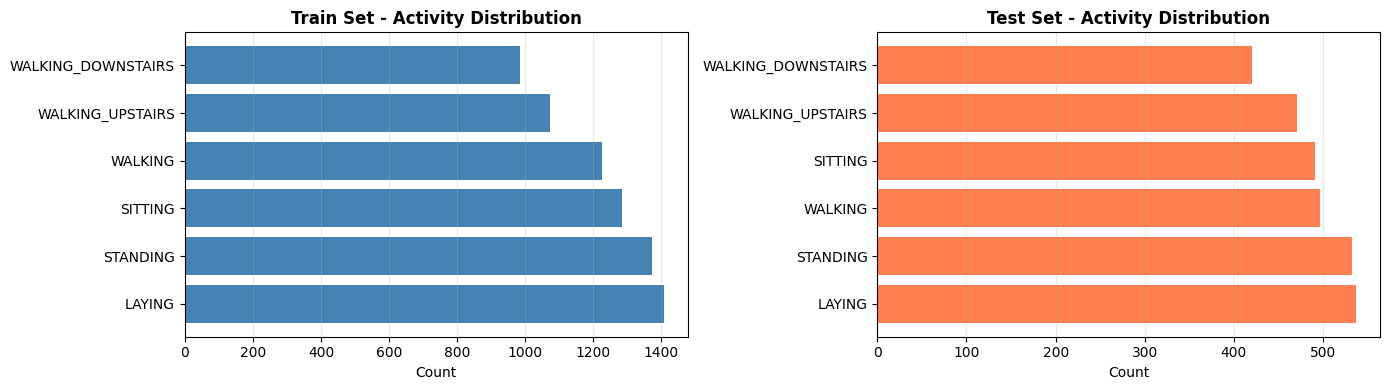

Train set size: 7352, Test set size: 2947


In [18]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

activity_counts_train = pd.Series(y_train).map(activity_map).value_counts()
axes[0].barh(activity_counts_train.index, activity_counts_train.values, color='steelblue')
axes[0].set_title('Train Set - Activity Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].grid(axis='x', alpha=0.3)

# Test set
activity_counts_test = pd.Series(y_test).map(activity_map).value_counts()
axes[1].barh(activity_counts_test.index, activity_counts_test.values, color='coral')
axes[1].set_title('Test Set - Activity Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Train set size: {len(y_train)}, Test set size: {len(y_test)}")

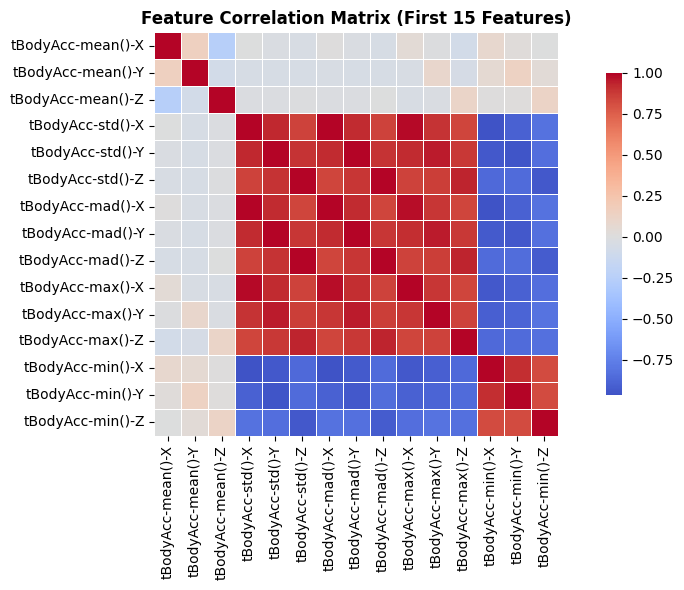


Dataset Overview:
- Train samples: 7352, Test samples: 2947
- Total features: 561
- Activities: 6
- Total subjects: 21


In [20]:
# Correlation heatmap - first 20 features
fig, ax = plt.subplots(figsize=(10, 6))

features_subset = X_train.drop('subject', axis=1).iloc[:, :15]  # First 15 features
correlation_matrix = features_subset.corr()

sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, ax=ax, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Feature Correlation Matrix (First 15 Features)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nDataset Overview:")
print(f"- Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"- Total features: {len(feature_names)}")
print(f"- Activities: {len(activity_map)}")
print(f"- Total subjects: {X_train['subject'].nunique()}")

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


models = {
    "Decision Tree":      (DecisionTreeClassifier(random_state=42),              False),
    "Random Forest":      (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), False),
    "Logistic Regression":(LogisticRegression(max_iter=1000, C=1.0, random_state=42), True),
    "Linear SVC":         (LinearSVC(C=1.0, max_iter=2000, random_state=42),     True),
    "RBF SVM":            (SVC(kernel='rbf', C=10, gamma='scale', random_state=42), True),
    "K-Nearest Neighbor": (KNeighborsClassifier(n_neighbors=5, n_jobs=-1),       True),
}

In [50]:
models

{'Decision Tree': (DecisionTreeClassifier(random_state=42), False)}

In [11]:
import time
results = []

for name, (model, use_scaled) in models.items():
    print(f"Training {name}...")
    Xtr = X_train_scaled if use_scaled else X_train
    Xte = X_test_scaled  if use_scaled else X_test
    start = time.time()
    model.fit(Xtr, y_train)
    end = time.time()
    training_time = round(end - start, 2)
    print(f"Trained {name} in {training_time} seconds.")
    y_pred = model.predict(Xte)

    results.append({
        "Model":     name,
        "Precision": round(precision_score(y_test, y_pred, average='weighted'), 2),
        "Recall":    round(recall_score   (y_test, y_pred, average='weighted'), 2),
        "F1-Score":  round(f1_score       (y_test, y_pred, average='weighted'), 2),
        "Accuracy":  round(accuracy_score (y_test, y_pred), 2),
        "Training Time": training_time
    })

Training Decision Tree...
Trained Decision Tree in 3.91 seconds.
Training Random Forest...
Trained Random Forest in 1.76 seconds.
Training Logistic Regression...
Trained Logistic Regression in 1.24 seconds.
Training Linear SVC...
Trained Linear SVC in 11.91 seconds.
Training RBF SVM...
Trained RBF SVM in 1.5 seconds.
Training K-Nearest Neighbor...
Trained K-Nearest Neighbor in 0.01 seconds.


In [12]:
results

[{'Model': 'Decision Tree',
  'Precision': 0.86,
  'Recall': 0.86,
  'F1-Score': 0.86,
  'Accuracy': 0.86,
  'Training Time': 3.91},
 {'Model': 'Random Forest',
  'Precision': 0.92,
  'Recall': 0.92,
  'F1-Score': 0.92,
  'Accuracy': 0.92,
  'Training Time': 1.76},
 {'Model': 'Logistic Regression',
  'Precision': 0.96,
  'Recall': 0.95,
  'F1-Score': 0.95,
  'Accuracy': 0.95,
  'Training Time': 1.24},
 {'Model': 'Linear SVC',
  'Precision': 0.96,
  'Recall': 0.96,
  'F1-Score': 0.96,
  'Accuracy': 0.96,
  'Training Time': 11.91},
 {'Model': 'RBF SVM',
  'Precision': 0.96,
  'Recall': 0.95,
  'F1-Score': 0.95,
  'Accuracy': 0.95,
  'Training Time': 1.5},
 {'Model': 'K-Nearest Neighbor',
  'Precision': 0.89,
  'Recall': 0.88,
  'F1-Score': 0.88,
  'Accuracy': 0.88,
  'Training Time': 0.01}]